# Quantum String Matching
## Projeto Final: Computação Quântica | Grupo 5 (String Match)
### Baseado em: Niroula & Nam, *A quantum algorithm for string matching*, npj Quantum Information (2021)

In [1]:
%pip install qiskit==2.4.1 qiskit-ibm-runtime==0.46.1 qiskit-aer==0.17.2 matplotlib pylatexenc --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, phase_damping_error
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt
import math
import os

Matplotlib is building the font cache; this may take a moment.


In [3]:
def encode_string(qc, register, bitstring):
    """
    Aplica a porta X em todo qubit j, em que bitstring[j] == 1
    """
    for j, bit in enumerate(bitstring):
        if bit == '1':
            qc.x(register[j])

In [4]:
def controlled_cyclic_shift(qc, control_qubit, text_reg, shift_amount):
    """
    Aplica o shift apenas quando o `control_qubit` está em |1⟩

    Aqui utilizamos portas CSWAP (ou portas de Fredkin)
    """
    n = len(text_reg)
    c = shift_amount % n

    if c == 0:
        return

    visited = [False] * n

    for start in range(n):
        if visited[start]:
            continue
        cycle = []
        cur = start

        while not visited[cur]:
            visited[cur] = True
            cycle.append(cur)
            cur = (cur + c) % n

        for k in range(len(cycle) - 1):
            qc.cswap(control_qubit, text_reg[cycle[k]], text_reg[cycle[k + 1]])

In [5]:
def build_grover_oracle(qc, pattern_reg):
    """
    Constrói o oráculo de fase de Grover.
    Flipa a fase de `pattern_reg` quando for |0...0⟩
    """
    m = len(pattern_reg)
    qc.x(pattern_reg)

    qc.h(pattern_reg[m - 1])
    qc.mcx(list(pattern_reg[:m - 1]), pattern_reg[m - 1])
    qc.h(pattern_reg[m - 1])

    qc.x(pattern_reg)

In [6]:
def build_grover_diffuser(qc, index_reg):
    """
    Difusor de Grover padrão:
        H⊗k -> X⊗k -> multi-controlled Z -> X⊗k -> H⊗k
    """

    k = len(index_reg)
    qc.h(index_reg)

    qc.x(index_reg)

    qc.h(index_reg[k - 1])
    qc.mcx(list(index_reg[:k - 1]), index_reg[k - 1])
    qc.h(index_reg[k - 1])

    qc.x(index_reg)

    qc.h(index_reg)

In [7]:
def _phase_flip_state(qc, index_reg, i_val, n_idx):
    i_bin = format(i_val, f'0{n_idx}b')  # MSB na esquerda, len(n_idx)
    zero_bits = [bit for bit in range(n_idx) if i_bin[n_idx - 1 - bit] == '0']

    for bit in zero_bits:
        qc.x(index_reg[bit])
    qc.h(index_reg[n_idx - 1])

    if n_idx > 1:
        qc.mcx(list(index_reg[:n_idx - 1]), index_reg[n_idx - 1])
    else:
        qc.x(index_reg[0])
    qc.h(index_reg[n_idx - 1])

    for bit in zero_bits:
        qc.x(index_reg[bit])


def build_string_match_circuit(text: str, pattern: str, n_iterations: int = None) -> QuantumCircuit:
    """
    Coração da implementação, tradução do circuito de Niroula & Nam (2001) para o Qiskit

    Args:
        text:         string binária, e.g. "1011"
        pattern:      string binária, e.g. "11"
        n_iterations: Quantidade de iterações de Grover. Se não for passada, computar **classicamente** seguindo a fórmula:
                      - 1 se não houver match
                      - 0 se houver chance de super-rotação
                      - floor(pi/4 * sqrt(2^n_idx / k)), caso contrário

    Layout dos registradores:
        q_idx:  ceil(log2(N-M+1)) qubits  -- Ancillas em superposição
        q_text: N qubits                  -- Encoding do Texto
        q_pat:  M qubits                  -- Encoding do padrão
        c_out:  ceil(log2(N-M+1)) bits    -- Output da medição
    """
    N = len(text)
    M = len(pattern)
    search_space = N - M + 1

    if search_space <= 0:
        raise ValueError("Pattern is longer than text.")

    n_idx = math.ceil(math.log2(max(search_space, 2)))

    if n_iterations is None:
        # Processamento clássico do número de matches
        n_valid_matches = sum(
            1 for i in range(search_space)
            if all(text[i + j] == pattern[j] for j in range(M))
        )
        if n_valid_matches == 0:
            n_iterations = 1  # Sem matches: 1 iteração apenas
        else:
            # Caso ótimo: floor(pi/4 * sqrt(N_eff / k)).
            # Se k >= N_eff/2, 0 iterações para não ter super-rotação.
            n_iterations = max(0, math.floor(
                math.pi / 4 * math.sqrt(2**n_idx / n_valid_matches)
            ))

    q_idx  = QuantumRegister(n_idx,  name="idx")
    q_text = QuantumRegister(N,      name="txt")
    q_pat  = QuantumRegister(M,      name="pat")
    c_out  = ClassicalRegister(n_idx, name="c_out")

    qc = QuantumCircuit(q_idx, q_text, q_pat, c_out)

    # Pré-comptua matches em posições inválidas, por conta do wrap-around
    spurious = [
        i for i in range(search_space, 2**n_idx)
        if all(text[(i + j) % N] == pattern[j] for j in range(M))
    ]

    # --- 1: Preparção do estado ---
    encode_string(qc, q_text, text)
    encode_string(qc, q_pat, pattern)
    qc.h(q_idx)
    qc.barrier()

    # ---Grover ---
    for _ in range(n_iterations):
        # 2: Controlled cyclic shift
        for bit in range(n_idx):
            shift_amount = (1 << bit) % N
            if shift_amount > 0:
                controlled_cyclic_shift(qc, q_idx[bit], q_text, shift_amount)
        qc.barrier()

        # 3: XOR
        for j in range(M):
            qc.cx(q_text[j], q_pat[j])
        qc.barrier()

        # 4: Oráculo de Grover
        build_grover_oracle(qc, q_pat)
        qc.barrier()

        # 5: Uncompute XOR
        for j in range(M):
            qc.cx(q_text[j], q_pat[j])
        qc.barrier()

        # 6: Uncompute cyclic shift.
        for bit in range(n_idx - 1, -1, -1):
            shift_amount = (1 << bit) % N
            inv_shift = (N - shift_amount) % N
            if inv_shift > 0:
                controlled_cyclic_shift(qc, q_idx[bit], q_text, inv_shift)
        qc.barrier()

        # Cancela wrap-around matches inválidos
        for i_sp in spurious:
            _phase_flip_state(qc, q_idx, i_sp, n_idx)
        if spurious:
            qc.barrier()

        # 7: Difusor de Grover no registrador de ancillas
        build_grover_diffuser(qc, q_idx)
        qc.barrier()

    # 8: Medir registrador de ancillas
    qc.measure(q_idx, c_out)

    return qc

Circuito: 8 qubits, profundidade 29
Min requerido: 5 qubits — PASS


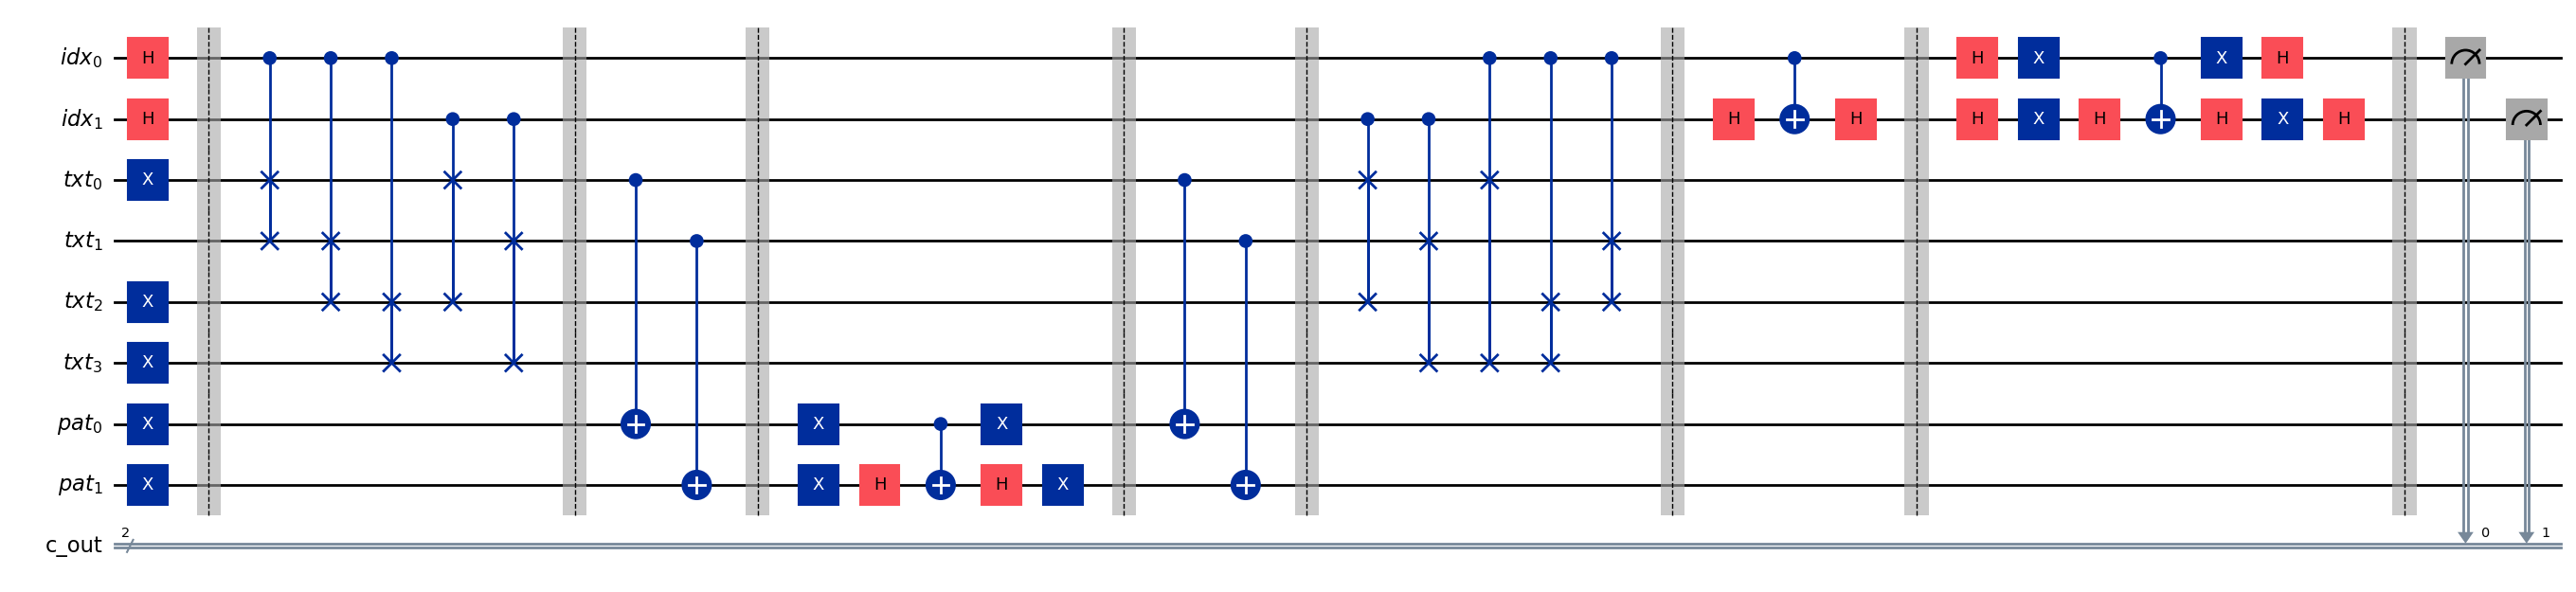

In [8]:
text, pattern = "1011", "11"
qc = build_string_match_circuit(text, pattern)
print(f"Circuito: {qc.num_qubits} qubits, profundidade {qc.depth()}")
print(f"Min requerido: 5 qubits — {'PASS' if qc.num_qubits >= 5 else 'FAIL'}")
qc.draw("mpl", fold=80)

In [9]:
def interpret_counts(counts, n_idx, search_space=None):
    """
    Converte bitstrings de medições em posições inteiras e retorna um dicionário ordenado na forma: {position: count}
    """
    result = {}
    for bitstring, count in counts.items():
        position = int(bitstring, 2)
        if search_space is not None and position >= search_space:
            continue
        result[position] = result.get(position, 0) + count
    return dict(sorted(result.items())) if result else {0: 0}

In [10]:
from qiskit_aer.primitives import SamplerV2 as AerSampler

simulator = AerSimulator()
shots = 2048

test_cases = [
    ("1011",  "11",  {2}),        # 1 match
    ("1101",  "11",  {0}),        # match no início
    ("0011",  "11",  {2}),        # match no fim
    ("1111",  "11",  {0, 1, 2}),  # múltiplos matches
    ("1010",  "11",  set()),      # sem match
    ("10110", "110", {2}),        # padrão com len = 3
]

print(f"{'Text':<10} {'Pattern':<10} {'Expected':<15} {'Top position':<15} {'Result'}")
print("-" * 65)

aer_sampler = AerSampler()

for text, pattern, expected in test_cases:
    N, M = len(text), len(pattern)
    search_space = N - M + 1
    n_idx = math.ceil(math.log2(max(search_space, 2)))

    qc = build_string_match_circuit(text, pattern)

    job = aer_sampler.run([qc], shots=shots)
    result = job.result()
    counts = result[0].data.c_out.get_counts()

    # Utilizando o search_space para filtrar posições inválidas do wrap-around
    pos_counts = interpret_counts(counts, n_idx, search_space=search_space)
    top_pos = max(pos_counts, key=pos_counts.get)

    if expected:
        passed = top_pos in expected
    else:
        # Sem match: As posições devem ter distribuições relativamente uniformes
        total = sum(pos_counts.values())
        max_count = max(pos_counts.values()) if pos_counts else 0
        passed = total == 0 or max_count / total < 0.5

    status = "PASS" if passed else "FAIL"
    print(f"{text:<10} {pattern:<10} {str(expected):<15} {str(top_pos):<15} {status}")

Text       Pattern    Expected        Top position    Result
-----------------------------------------------------------------
1011       11         {2}             2               PASS
1101       11         {0}             0               PASS
0011       11         {2}             2               PASS
1111       11         {0, 1, 2}       2               PASS
1010       11         set()           0               PASS
10110      110        {2}             2               PASS


## Variações Parametrizadas

O projeto exige no mínimo 10 variações de circuito. Aqui variamos:
- O texto (comprimento e conteúdo)
- O padrão (comprimento e conteúdo)
- O número de iterações de Grover (padrão, sub-rotação e super-rotação)

Isso nos permite estudar como cada parâmetro afeta a qualidade da busca.

In [11]:
from qiskit_aer.primitives import SamplerV2 as AerSampler

variations = [
    # (text,        pattern, n_iter, description)
    ("1011",      "11",   None,  "caso base — 1 match"),
    ("1101",      "11",   None,  "match no início"),
    ("0011",      "11",   None,  "match no final"),
    ("1111",      "11",   None,  "múltiplos matches"),
    ("1010",      "11",   None,  "sem match"),
    ("10110",     "110",  None,  "padrão comprimento 3"),
    ("101101",    "110",  None,  "texto mais longo"),
    ("1011",      "11",   1,     "1 iteração de Grover"),
    ("1011",      "11",   2,     "2 iterações de Grover"),
    ("1011",      "11",   3,     "3 iterações (super-rotação)"),
    ("00110011",  "11",   None,  "N=8, dois matches"),
    ("11001100",  "00",   None,  "N=8, padrão '00'"),
]

aer_sampler = AerSampler()
shots = 1024

results_table = []

print(f"{'#':<3} {'Texto':<12} {'Padrão':<8} {'Iter':<5} {'Top pos':<10} {'Prob top':<10} Descrição")
print("-" * 80)

for idx, (text, pattern, n_iter, desc) in enumerate(variations):
    N, M = len(text), len(pattern)
    search_space = N - M + 1
    n_idx = math.ceil(math.log2(max(search_space, 2)))

    qc = build_string_match_circuit(text, pattern, n_iter)

    # Computando a quantidade de iterações para mostrar na tabela
    if n_iter is not None:
        actual_iter = n_iter
    else:
        nvm = sum(1 for i in range(search_space) if all(text[i+j]==pattern[j] for j in range(M)))
        if nvm == 0:
            actual_iter = 1
        else:
            actual_iter = max(0, math.floor(math.pi / 4 * math.sqrt(2**n_idx / nvm)))

    job = aer_sampler.run([qc], shots=shots)
    result = job.result()
    counts = result[0].data.c_out.get_counts()

    pos_counts = interpret_counts(counts, n_idx, search_space=search_space)

    if not pos_counts:
        pos_counts = {0: 0}
    top_pos = max(pos_counts, key=pos_counts.get)
    prob_top = pos_counts[top_pos] / shots

    results_table.append((text, pattern, actual_iter, top_pos, prob_top, pos_counts, desc))
    print(f"{idx+1:<3} {text:<12} {pattern:<8} {actual_iter:<5} {top_pos:<10} {prob_top:.2%}    {desc}")

#   Texto        Padrão   Iter  Top pos    Prob top   Descrição
--------------------------------------------------------------------------------
1   1011         11       1     2          100.00%    caso base — 1 match
2   1101         11       1     0          100.00%    match no início
3   0011         11       1     2          100.00%    match no final
4   1111         11       0     1          26.17%    múltiplos matches
5   1010         11       1     2          27.64%    sem match
6   10110        110      1     2          100.00%    padrão comprimento 3
7   101101       110      1     2          100.00%    texto mais longo
8   1011         11       1     2          100.00%    1 iteração de Grover
9   1011         11       2     0          25.29%    2 iterações de Grover
10  1011         11       3     0          26.95%    3 iterações (super-rotação)
11  00110011     11       1     2          50.39%    N=8, dois matches
12  11001100     00       1     6          50.20%    N=8, pa

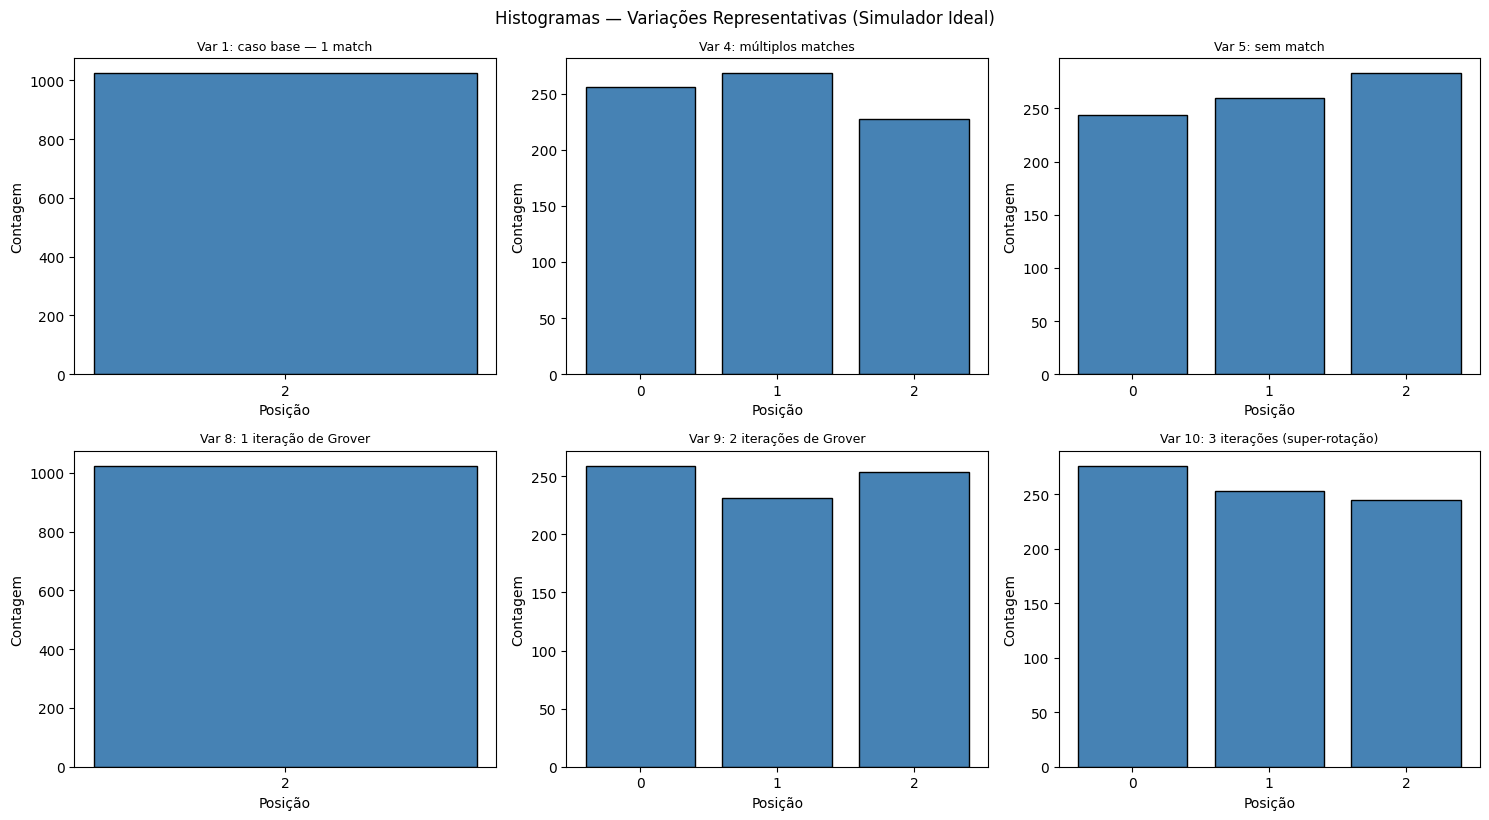

In [12]:
# Histogramas para casos representativos
representative = [0, 3, 4, 7, 8, 9]  # índices de casos interessantes

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax_idx, var_idx in enumerate(representative):
    text, pattern, n_iter, top_pos, prob_top, pos_counts, desc = results_table[var_idx]
    positions = list(pos_counts.keys())
    counts_vals = [pos_counts[p] for p in positions]

    axes[ax_idx].bar(positions, counts_vals, color='steelblue', edgecolor='black')
    axes[ax_idx].set_title(f"Var {var_idx+1}: {desc}", fontsize=9)
    axes[ax_idx].set_xlabel("Posição")
    axes[ax_idx].set_ylabel("Contagem")
    axes[ax_idx].set_xticks(positions)

plt.tight_layout()
plt.suptitle("Histogramas — Variações Representativas (Simulador Ideal)", y=1.02, fontsize=12)
plt.show()

## Análise de Ruído

### Modelo de Ruído

Para estudar o impacto do ruído, aplicamos dois tipos de erro ao simulador:

1. **Erro depolarizante (`depolarizing_error`):** Em cada porta quântica, o qubit tem probabilidade `p` de sofrer uma operação aleatória (X, Y ou Z com probabilidade p/3 cada). Este é o modelo de ruído mais comum em hardware real.

2. **Amortecimento de fase (`phase_damping_error`):** Modela a perda de coerência sem perda de energia (dephasing) — o qubit perde a informação de fase com probabilidade `γ`. É uma perturbação mais sutil que o erro depolarizante.

### Objetivo

Encontrar o **limiar de ruído** acima do qual a saída do algoritmo começa a degradar — ou seja, onde a posição correta deixa de ser o resultado mais provável.

Ruído depolarizante p=0.000: P(posição correta=2) = 1.000
Ruído depolarizante p=0.001: P(posição correta=2) = 0.972
Ruído depolarizante p=0.005: P(posição correta=2) = 0.889
Ruído depolarizante p=0.010: P(posição correta=2) = 0.821
Ruído depolarizante p=0.020: P(posição correta=2) = 0.661
Ruído depolarizante p=0.050: P(posição correta=2) = 0.425
Ruído depolarizante p=0.100: P(posição correta=2) = 0.290


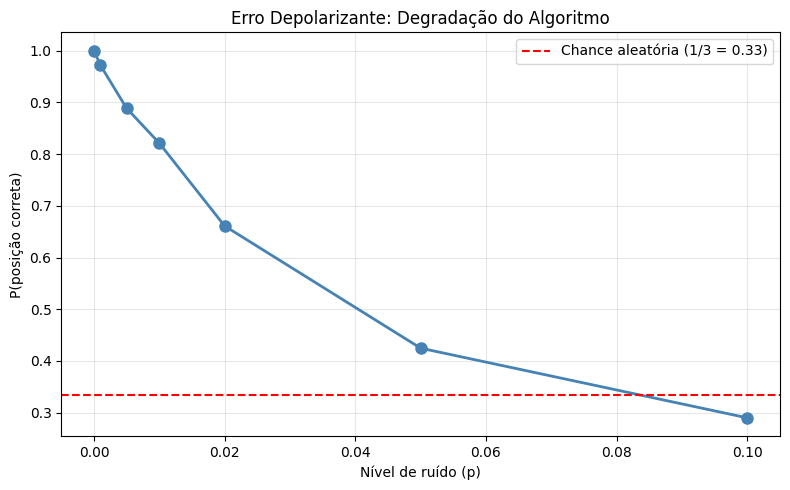

In [13]:
from qiskit import transpile

noise_levels = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
text, pattern = "1011", "11"
expected_pos = 2
shots = 1024

N, M = len(text), len(pattern)
search_space = N - M + 1
n_idx = math.ceil(math.log2(max(search_space, 2)))
qc = build_string_match_circuit(text, pattern)

depol_probs = []

for p in noise_levels:
    if p == 0.0:
        sim = AerSimulator()
    else:
        noise_model = NoiseModel()
        err1 = depolarizing_error(p, 1)
        err2 = depolarizing_error(p, 2)
        err3 = depolarizing_error(p, 3)
        noise_model.add_all_qubit_quantum_error(err1, ['h', 'x', 's', 't'])
        noise_model.add_all_qubit_quantum_error(err2, ['cx', 'cz', 'swap'])
        noise_model.add_all_qubit_quantum_error(err3, ['cswap', 'ccx'])
        sim = AerSimulator(noise_model=noise_model)

    qc_t = transpile(qc, sim)
    result = sim.run(qc_t, shots=shots).result()
    counts = result.get_counts()

    pos_counts = interpret_counts(counts, n_idx, search_space=search_space)
    prob_correct = pos_counts.get(expected_pos, 0) / shots
    depol_probs.append(prob_correct)
    print(f"Ruído depolarizante p={p:.3f}: P(posição correta={expected_pos}) = {prob_correct:.3f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, depol_probs, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axhline(y=1/search_space, color='red', linestyle='--',
            label=f'Chance aleatória (1/{search_space} = {1/search_space:.2f})')
plt.xlabel("Nível de ruído (p)")
plt.ylabel("P(posição correta)")
plt.title("Erro Depolarizante: Degradação do Algoritmo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Amortecimento de fase γ=0.000: P(posição correta=2) = 1.000
Amortecimento de fase γ=0.001: P(posição correta=2) = 0.991
Amortecimento de fase γ=0.005: P(posição correta=2) = 0.958
Amortecimento de fase γ=0.010: P(posição correta=2) = 0.929
Amortecimento de fase γ=0.020: P(posição correta=2) = 0.873
Amortecimento de fase γ=0.050: P(posição correta=2) = 0.698
Amortecimento de fase γ=0.100: P(posição correta=2) = 0.509


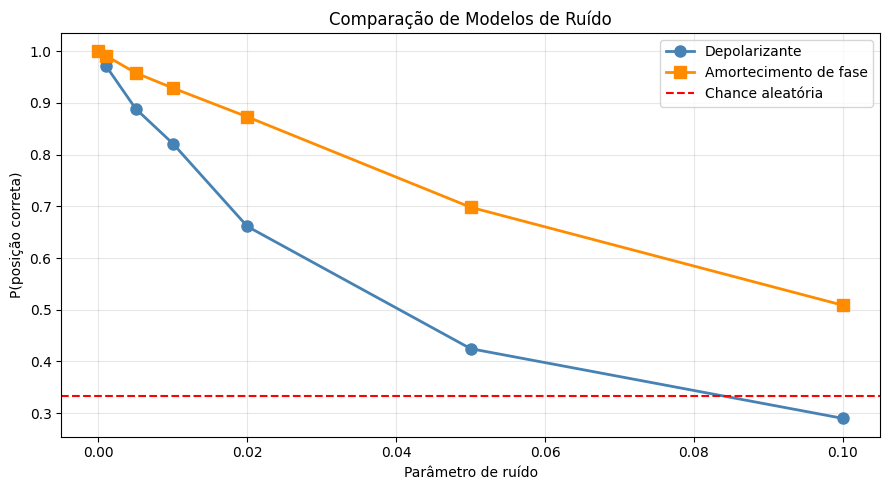

In [14]:
phase_probs = []

for gamma in noise_levels:
    if gamma == 0.0:
        sim = AerSimulator()
    else:
        noise_model = NoiseModel()
        err1 = phase_damping_error(gamma)
        noise_model.add_all_qubit_quantum_error(err1, ['h', 'x', 's', 't'])
        sim = AerSimulator(noise_model=noise_model)

    qc_t = transpile(qc, sim)
    result = sim.run(qc_t, shots=shots).result()
    counts = result.get_counts()

    pos_counts = interpret_counts(counts, n_idx, search_space=search_space)
    prob_correct = pos_counts.get(expected_pos, 0) / shots
    phase_probs.append(prob_correct)
    print(f"Amortecimento de fase γ={gamma:.3f}: P(posição correta={expected_pos}) = {prob_correct:.3f}")

# Comparação dos dois tipos de ruído
plt.figure(figsize=(9, 5))
plt.plot(noise_levels, depol_probs,  'o-', color='steelblue',  linewidth=2, markersize=8, label='Depolarizante')
plt.plot(noise_levels, phase_probs,  's-', color='darkorange', linewidth=2, markersize=8, label='Amortecimento de fase')
plt.axhline(y=1/search_space, color='red', linestyle='--', label='Chance aleatória')
plt.xlabel("Parâmetro de ruído")
plt.ylabel("P(posição correta)")
plt.title("Comparação de Modelos de Ruído")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Execução em Hardware Real IBM Quantum

### Configuração

Para executar em hardware real é necessário:
1. Uma conta no [IBM Quantum](https://quantum.ibm.com/)
2. Definir o token de acesso na variável de ambiente antes de iniciar o Jupyter:
   ```bash
   export IBM_TOKEN="seu_token_aqui"
   ```

### Backends X e Y

Usamos dois backends reais diferentes para a comparação exigida pelo projeto. O backend X é selecionado automaticamente como o menos ocupado (`least_busy`). O backend Y pode ser especificado manualmente para garantir um dispositivo diferente.

In [ ]:
token = os.environ.get("IBM_TOKEN")
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token)

backend_X = service.least_busy(simulator=False, operational=True)
print(f"Backend X: {backend_X.name}")

# Backend Y: escolher manualmente um segundo backend disponível
all_backends = service.backends(simulator=False, operational=True)
backend_Y = next((b for b in all_backends if b.name != backend_X.name), None)
if backend_Y:
    print(f"Backend Y: {backend_Y.name}")
else:
    print("Apenas um backend disponível — backend Y = backend X")
    backend_Y = backend_X

AccountNotFoundError: "Unable to find account. Please make sure an account with the channel name 'ibm_quantum_platform' is saved."

In [ ]:
text, pattern = "1011", "11"
qc_small = build_string_match_circuit(text, pattern)

pm = generate_preset_pass_manager(backend=backend_X, optimization_level=1)
isa_circuit_x = pm.run(qc_small)
print(f"Profundidade transpilada (backend X): {isa_circuit_x.depth()}")

pm = generate_preset_pass_manager(backend=backend_Y, optimization_level=1)
isa_circuit_y = pm.run(qc_small)
print(f"Profundidade transpilada (backend Y): {isa_circuit_y.depth()}")

sampler_x = Sampler(mode=backend_X)
job_x = sampler_x.run([isa_circuit_x], shots=1024)
print(f"Job X ID: {job_x.job_id()} — aguardando resultado...")
result_x = job_x.result()
counts_hw_X = result_x[0].data.c_out.get_counts()

sampler_y = Sampler(mode=backend_Y)
job_y = sampler_y.run([isa_circuit_y], shots=1024)
print(f"Job Y ID: {job_y.job_id()} — aguardando resultado...")
result_y = job_y.result()
counts_hw_Y = result_y[0].data.c_out.get_counts()

fig = plot_histogram(counts_hw_X, title=f"IBM Hardware Real ({backend_X.name})")
display(fig)

fig = plot_histogram(counts_hw_Y, title=f"IBM Hardware Real ({backend_Y.name})")
display(fig)

In [ ]:
# Emulação ruidosa dos backends reais com AerSimulator

# Backend X
noise_model_X = NoiseModel.from_backend(backend_X)
sim_noisy_X = AerSimulator(noise_model=noise_model_X)
qc_t_X = transpile(qc_small, sim_noisy_X)
result_noisy_X = sim_noisy_X.run(qc_t_X, shots=1024).result()
counts_noisy_X = result_noisy_X.get_counts()
print(f"Simulador ruidoso emulando {backend_X.name}: top result = {max(counts_noisy_X, key=counts_noisy_X.get)}")

# Backend Y
noise_model_Y = NoiseModel.from_backend(backend_Y)
sim_noisy_Y = AerSimulator(noise_model=noise_model_Y)
qc_t_Y = transpile(qc_small, sim_noisy_Y)
result_noisy_Y = sim_noisy_Y.run(qc_t_Y, shots=1024).result()
counts_noisy_Y = result_noisy_Y.get_counts()
print(f"Simulador ruidoso emulando {backend_Y.name}: top result = {max(counts_noisy_Y, key=counts_noisy_Y.get)}")

fig = plot_histogram(counts_noisy_X, title=f"Emulador Ruidoso ({backend_X.name})")
display(fig)

fig = plot_histogram(counts_noisy_Y, title=f"Emulador Ruidoso ({backend_Y.name})")
display(fig)